# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [180]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [109]:
# cargar archivos
plans= pd.read_csv("/datasets/plans.csv")
users= pd.read_csv("/datasets/users_latam.csv")
usage= pd.read_csv("/datasets/usage.csv")

In [110]:
plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [111]:
users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN
...,...,...,...,...,...,...,...,...
3995,13995,Ana,Lopez,60,Medellín,2024-12-29 21:42:48.342085520,Basico,NaN
3996,13996,Carlos,Ramirez,24,Medellín,2024-12-30 04:17:06.256564144,Premium,NaN
3997,13997,Ana,Lopez,58,Bogotá,2024-12-30 10:51:24.171042768,Premium,NaN
3998,13998,Mariana,Lopez,57,Bogotá,2024-12-30 17:25:42.085521392,Basico,NaN


In [112]:
usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN
...,...,...,...,...,...,...
39995,39996,13497,call,2024-06-29 23:33:56.120903022,5.75,NaN
39996,39997,10941,call,2024-06-29 23:40:27.090677266,3.06,NaN
39997,39998,13038,call,2024-06-29 23:46:58.060451510,8.74,NaN
39998,39999,10863,text,2024-06-29 23:53:29.030225754,NaN,43.0


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [113]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [114]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [115]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [116]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [117]:
# cantidad de nulos para users

print(users.isna().sum())
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [118]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  

- ¿Qué columnas tienen valores faltantes y en qué proporción?
- User: City (11%) y churn_date (88%)
- Usage: Date (0.1%), Duration (55%) y length(44%)
- Indica qué harías: ¿imputar, eliminar, ignorar?
- Users: Para city, podría imputarse un valor como "Unknown" debido a que el porcentaje de faltantes es relativamente bajo. En cambio, los nulos de churn_date probablemente representan usuarios que aún no han cancelado el servicio, por lo que conservaría estos valores y los interpretaría como clientes activos en lugar de imputarlos o eliminarlos.
- Usage: Dado que los nulos en date son mínimos, eliminaría esos registros sin afectar significativamente el análisis. Para duration y length, no imputaría valores de forma inmediata, ya que es posible que los nulos dependan del tipo de actividad registrada (por ejemplo, llamadas o mensajes) y tengan un significado válido dentro del negocio.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [119]:

users["user_id"].describe()
users["age"].describe()


count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

- La columna `user_id` ... La columna user_id tiene 4.000 registros, sin valores faltantes, con identificadores entre 10.000 y 13.999. La media (11.999,5) y la mediana (11.999,5) son iguales, lo que indica una distribución uniforme de los IDs. Al ser una variable identificadora
- La columna `age` ... tiene 4.000 registros, con una edad promedio de 33,74 años y una mediana de 47 años. La mayoría de los usuarios tienen edades entre 32 y 63 años (rango intercuartílico). Sin embargo, el valor mínimo es -999, lo que indica un dato inválido o un valor utilizado para representar información faltante, por lo que debería revisarse antes de realizar análisis posteriores.

In [120]:
usage["user_id"].describe()
usage["id"].describe()

count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64

- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ... user_id,tiene 40.000 registros, con valores entre 10.000 y 13.999. La media (12.002,41) y la mediana (12.013) son muy similares, lo que sugiere una distribución equilibrada de los registros entre los usuarios. Esta variable funciona como identificador
- id tiene 40.000 registros, con valores consecutivos entre 1 y 40.000. La media (20.000,5) coincide con la mediana (20.000,5), lo que indica una distribución uniforme. Al igual que user_id, esta es una variable identificadora y su principal utilidad es identificar de forma única cada registro del dataset.

In [121]:
# explorar columnas categóricas de users
users["city"].value_counts()
users["plan"].value_counts()

Basico     2595
Premium    1405
Name: plan, dtype: int64

- La columna `city` ... Tiene 96 valores sin reconocer
- La columna `plan` ... Todo en orden

In [122]:
# explorar columna categórica de usage
usage["type"].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` ... Todo en orden


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?   En la columna city habia valoroes sin reconocer o marcados como "?"
- ¿Qué acción tomarías? Los trataría como valores faltantes, ya que no representan una ciudad válida. Primero los reemplazaría por NaN para unificar los datos faltantes y luego los imputaría con una categoría como "Unknown" o "No registrado", evitando perder registros que podrían ser útiles para el análisis.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [123]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors = "coerce")

In [124]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"],errors = "coerce")

In [125]:
# Revisar los años presentes en `reg_date` de users
users["reg_date"].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves. Se evidencia que el data esta completa del 2022 al 2024

In [126]:
# Revisar los años presentes en `date` de usage
usage["date"].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  Información netamente del 2024.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas? hay información no acorde a los años del dataset, las dejaria marcadas como "Na"

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [127]:


# Reemplazar -999 por la mediana de age
age_mediana = users[users["age"] != -999]["age"].median()
users['age']= users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [128]:
# Reemplazar ? por NA en city
users['city'] = users["city"].replace("?",pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [129]:


# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"].dt.year > 2024, "reg_date"] = pd.NaT


# Verificar cambios
users['reg_date'].describe()


count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [133]:

# Verificación MAR en usage (Missing At Random) para duration
usage["duration_missing"] = usage["duration"].isna()


In [136]:
# Verificación MAR en usage (Missing At Random) para length
usage["length_missing"] = usage["length"].isna()
usage.groupby("type")[["duration_missing", "length_missing"]].mean()

,duration_missing,length_missing
type,,
call,0.000000,0.99933
text,0.999276,0.00000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length' Los nulos en duration y length son estructurales y dependen del tipo de comunicación. En los registros call, duration está informada y length es nula casi siempre (99.93%). En los registros text, ocurre lo contrario: length está informada y duration es nula en el 99.93% de los casos. Por ello, estos nulos son esperados y no representan un problema de calidad de datos.

---

## 🧩Paso 4: Summary statistics de uso por usuario



### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.
    

In [144]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas



# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(cant_mensajes=("is_text", "sum"),cant_llamadas=("is_call", "sum"),cant_minutos_llamada=("duration", "sum")).reset_index()


# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [146]:

# Renombrar columnas
usage.rename(columns={"is_text": "cant_mensajes","is_call": "cant_llamadas","duration": "cant_minutos_llamada"}, inplace = True)
# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [147]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on = "user_id")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [149]:
# Resumen estadístico de las columnas numéricas
columnas_num = ["age","cant_mensajes","cant_llamadas","cant_minutos_llamada"]
user_profile[columnas_num].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.138285,5.524381,4.478120,23.317054
std,17.691541,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [151]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize = True) * 100

Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

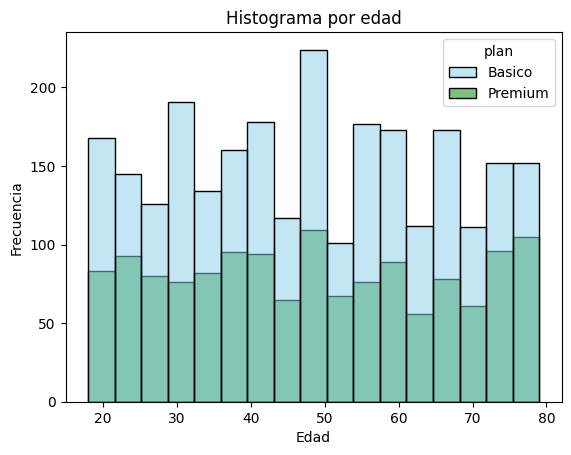

In [154]:

# Histograma para visualizar la edad (age)
sns.histplot(data = user_profile, x="age", hue="plan", palette=["skyblue","green"])
plt.title("Histograma por edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()


💡Insights: 
- La proporción entre plan Básico y Premium se mantiene relativamente estable en todos los grupos de edad. En general, el Básico representa aproximadamente el doble que el Premium. Esto indica que la edad no es un factor diferenciador del tipo de plan elegido

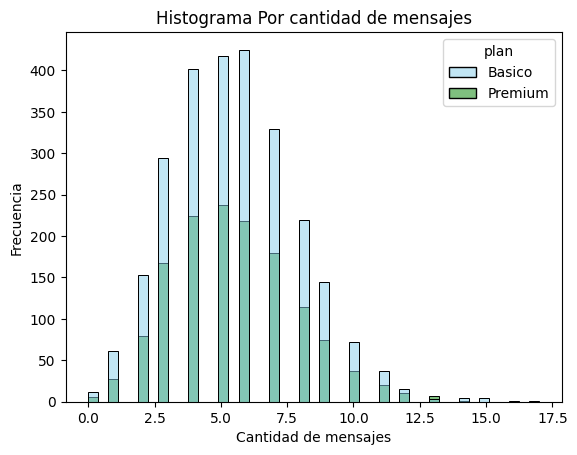

In [159]:

# Histograma para visualizar la cant_mensajes
sns.histplot(data = user_profile, x="cant_mensajes", hue="plan", palette=["skyblue","green"])
plt.title("Histograma Por cantidad de mensajes")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Frecuencia")
plt.show()



💡Insights: el usuario Premium es más activo, lo que tiene sentido con el tipo de plan, es decir, quien paga más, usa más el servicio.
- ....

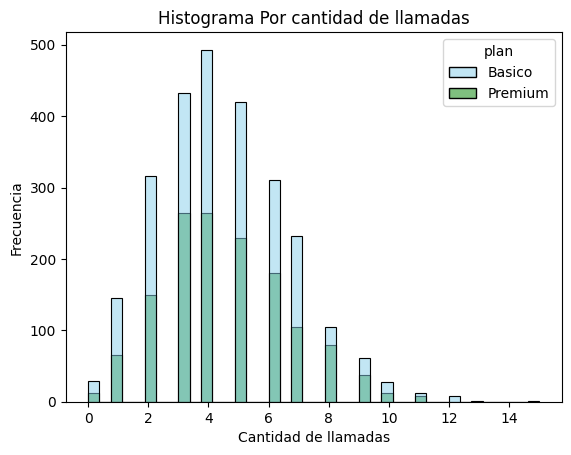

In [158]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data = user_profile, x="cant_llamadas", hue="plan", palette=["skyblue","green"])
plt.title("Histograma Por cantidad de llamadas")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Frecuencia")
plt.show()




💡Insights: 
- En rangos bajos de llamadas (0–3) el Básico predomina claramente, mientras que a partir de 4–5 llamadas los usuarios Premium representan una proporción mayor, llegando casi a igualar al Básico en 5–6 llamadas.

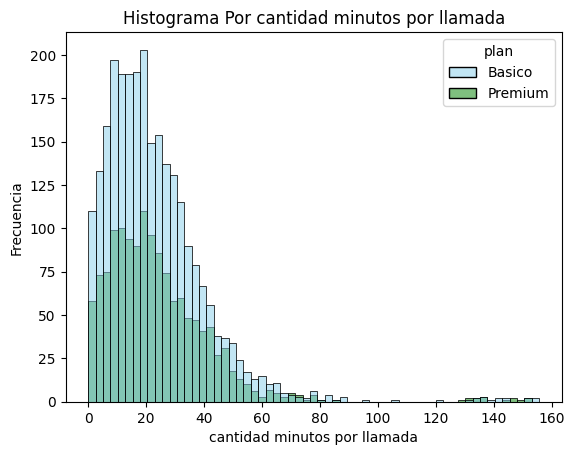

In [157]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data = user_profile, x="cant_minutos_llamada", hue="plan", palette=["skyblue","green"])
plt.title("Histograma Por cantidad minutos por llamada")
plt.xlabel("cantidad minutos por llamada")
plt.ylabel("Frecuencia")
plt.show()



💡Insights: 
- Ambos planes muestran una distribución sesgada a la derecha, concentrándose la mayoría de llamadas entre 0 y 40 minutos. Sin embargo, la diferencia clave está en la cola larga: las llamadas de más de 60 minutos son casi exclusivamente de usuarios Básico, prácticamente sin presencia Premium.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

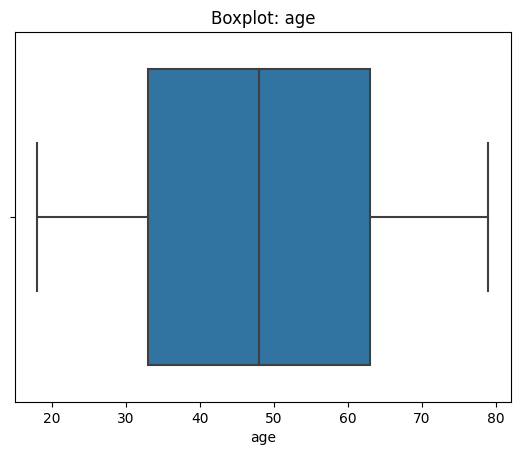

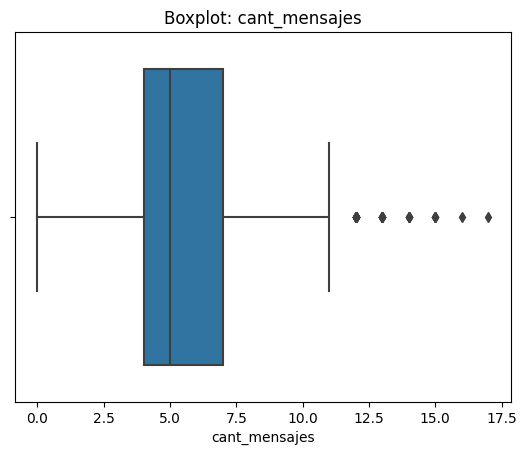

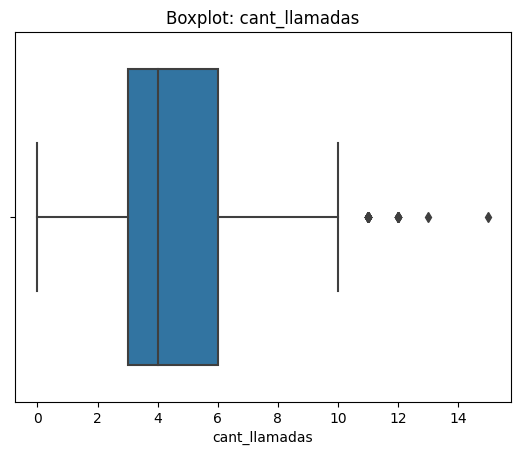

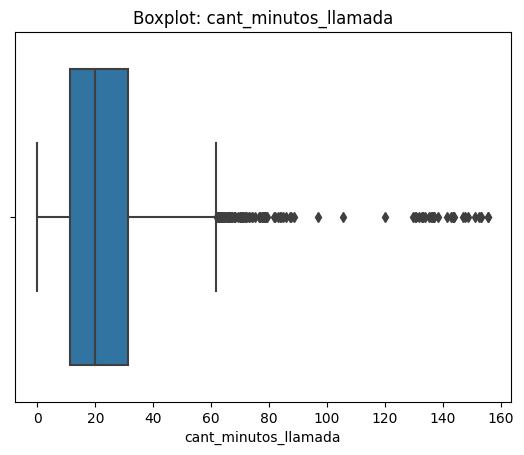

In [168]:




# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
        sns.boxplot(data=user_profile, x=col)
        plt.title(f'Boxplot: {col}')
        plt.show()





💡Insights: 
-Age: No presenta outliers
-Cant_mensajes: Sí presenta outliers en el extremo superior, visibles como puntos individuales entre 12.5 y 17.5 mensajes.
-Cant_llamadas: Sí presenta outliers en el extremo superior, con algunos puntos aislados entre 12 y 14 llamadas.
-Cant_minutos_llamada: Es la variable con más outliers y los más extremos,hay una cantidad considerable de puntos dispersos desde 80 hasta 160 minutos

In [175]:
# Calcular límites con el método IQR
columnas_limites = ["cant_minutos_llamada","cant_llamadas","cant_mensajes"]

for col in columnas_limites:
        Q1 = user_profile[col].quantile(0.25)
        Q3 = user_profile[col].quantile(0.75)
        IQR = Q1 - Q3
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR


In [176]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_minutos_llamada,cant_llamadas,cant_mensajes
count,3999.000000,3999.000000,3999.000000
mean,23.317054,4.478120,5.524381
std,18.168095,2.144238,2.358416
min,0.000000,0.000000,0.000000
25%,11.120000,3.000000,4.000000
50%,19.780000,4.000000,5.000000
75%,31.415000,6.000000,7.000000
max,155.690000,15.000000,17.000000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Mantener los outliers. El valor máximo (17 mensajes) no es excesivamente alto respecto a la distribución de los datos y puede representar usuarios con una mayor frecuencia de uso del servicio de mensajería.
- cant_llamadas: mantener o no outliers, porqué? Mantener los outliers. Aunque algunos usuarios realizan más llamadas que la mayoría, el máximo observado (15 llamadas) es razonable y corresponde a comportamientos reales de uso intensivo.
- cant_minutos_llamada: mantener o no outliers, porqué? Mantener los outliers. Los usuarios con una gran cantidad de minutos consumidos son relevantes para el negocio, ya que representan clientes de alto uso. El valor máximo (155.69 minutos) es plausible y no sugiere errores de captura o registro.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [182]:
# Crear columna grupo_uso

condiciones = [
    (user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5),
    (user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10)
]

valores = [
    "Bajo uso",
    "Uso medio"
]

user_profile["grupo_uso"] = np.select(
    condiciones,
    valores,
    default="Alto uso"
)


In [183]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [184]:
# Crear columna grupo_edad

import numpy as np

condiciones = [
    user_profile["age"] < 30,
    user_profile["age"] < 60
]

valores = [
    "Joven",
    "Adulto"
]

user_profile["grupo_edad"] = np.select(
    condiciones,
    valores,
    default="Adulto Mayor"
)

In [185]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

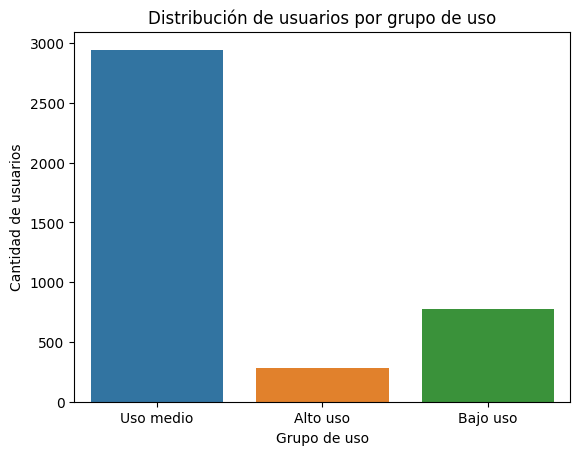

In [186]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x="grupo_uso")

plt.title("Distribución de usuarios por grupo de uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")
plt.show()

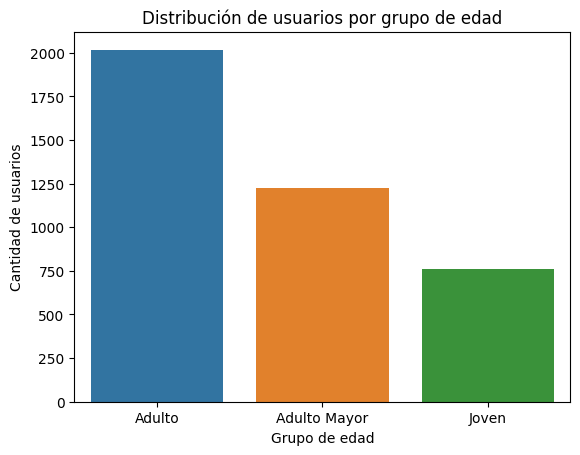

In [187]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x="grupo_edad")

plt.title("Distribución de usuarios por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de usuarios")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**





**Análisis Ejecutivo: Segmentación y Estrategia Comercial de ConnectaTel**

**1. Calidad de los Datos y Diagnóstico Inicial**
- Edades inválidas: Detectamos errores de captura (valores en -999) que afectaban al 1% de los usuarios; estos registros se normalizaron usando la mediana de edad (48 años).
- Ciudades incompletas: Un 14.1% de los perfiles no tenía la ciudad registrada o mostraba un signo de interrogación; se estandarizaron bajo la etiqueta "No registrado" para no perder su historial de consumo.
- Fechas inconsistentes: Se identificó un 1% de usuarios con fechas de registro anómalas que apuntaban al año 2026; estas se marcaron como nulas para evitar distorsiones en la línea de tiempo.
- Registros vacíos en consumo: Los valores nulos en la duración de llamadas y textos no son errores, sino la naturaleza del negocio (si el usuario manda un mensaje, la duración de la llamada es cero, y viceversa)

**2. Perfil del Consumidor y Segmentación**

- El Usuario Estándar (Plan Básico): Con una edad promedio de 48 años, mantiene un uso moderado y predecible, promediando 4 llamadas y 5 mensajes al mes sin rebasar sus límites.  
- El Usuario de Alto Valor (Plan Premium): Tienen un perfil de edad similar al básico, pero su intensidad de uso es considerablemente mayor, siendo los responsables de los consumos más altos de telefonía en la empresa.
- El Segmento Digital Joven: Clientes de entre 18 y 30 años que, si bien consumen minutos, muestran una clara tendencia hacia el uso intensivo de datos y mensajería rápida.

**3. ¿Cuáles son los segmentos más valiosos?**
- El mayor valor financiero inmediato proviene del Usuario de Alto Valor (Plan Premium). Aunque representan el 35.13% de la base, aportan el ARPU (ingreso promedio por usuario) más alto gracias a su tarifa mensual de $25 USD, además de ser clientes más fieles por el volumen de beneficios que reciben.  Por otro lado, el Plan Básico es el motor de rentabilidad por volumen. Al concentrar casi el 65% de los usuarios con un consumo de red mínimo (4 llamadas y 5 mensajes promedio), genera un margen operativo sumamente limpio y predecible.

**4. Patrones de Uso Extremo (Outliers) y Riesgos**
- El análisis identificó picos de consumo atípicos muy marcados. Mientras que un cliente promedio no pasa de 6 llamadas por evento, existen usuarios extremos que alcanzan hasta 15 llamadas recurrentes y registros de hasta 155 minutos en una sola llamada.
- Estos picos representan una carga pesada para la infraestructura en momentos de alta demanda.

**5. Recomendaciones Estratégicas**
- Lanzar un "Plan Intermedio" (Plan Flex): El salto actual entre el plan de 12 USD y el de 25 USD es demasiado grande. Propongo diseñar un plan de 18 USD con 12 GB, 300 minutos y 250 mensajes. Esto permitirá migrar a los usuarios básicos que necesitan más beneficios sin obligarlos a duplicar su gasto.  
- Paquetes de Mitigación de Excesos: Implementar alertas automáticas vía SMS cuando el usuario básico llegue al 80% de su capacidad, ofreciéndole "bolsas de minutos" económicas (ej. 50 minutos por 3 USD) para evitar el cobro por minuto estándar y mejorar la experiencia del cliente.
- Estrategia Anticipada de Retención: El histórico muestra que un 11.65% de los clientes ya se han dado de baja. Monitorear los patrones de consumo de los usuarios con uso extremo nos permitirá predecir el comportamiento de abandono y actuar con ofertas personalizadas antes de que cancelen el servicio.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`